In [10]:
import os
import sys
import gzip
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from limen import (Gene, Transcript, identifiability, build_matrix,
                   incidence_patterns, private_fraction, signature_owners,
                   read_signature, sweep, load_annotation, detect_format)
import limen

print("python :", sys.version.split()[0])
print("numpy  :", np.__version__)
print("limen  :", limen.__version__, "from", limen.__file__)
print("exports:", len(limen.__all__), "names")

python : 3.11.16
numpy  : 2.4.6
limen  : 0.1.0 from /Users/ib/Code/limen/src/limen/__init__.py
exports: 13 names


In [11]:
REF  = Path(os.environ.get("LIMEN_REF",  Path.home() / "Code" / "ReferenceGenome"))
WORK = Path(os.environ.get("LIMEN_WORK", Path.home() / "work" / "limen"))
(WORK / "results").mkdir(parents=True, exist_ok=True)

# annotations available on this machine
ANNOT = {
    "Chlamydomonas": REF / "CreinhardtiiCC_4532_707_v6.1.gene.gff3",
    "Arabidopsis"  : REF / "Araport11_GFF3_genes_transposons.201606.std_r_luc.gff3",
    "Oryza"        : REF / "IRGSP-1.0_representative_2020-09-09.rev2.std_r_luc.gff3",
    "Nicotiana"    : REF / "Niben101_annotation.gene_models.fix.std_r_luc.gff3",
}

# the read-length ladder: Illumina through to full-length long reads
READ_LENGTHS = [100, 150, 250, 300, 500, 1000, 2000, 4000, 8000, 16000]

# short-read paired-end grid, for comparison with published short-read work
FRAGMENT_LENGTHS = [200, 300, 400, 600, 900]

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (7, 4)

for name, p in ANNOT.items():
    size = f"{p.stat().st_size/1e6:.0f} MB" if p.exists() else "MISSING"
    print(f"{name:<15} {size:>8}  {p.name}")

Chlamydomonas      56 MB  CreinhardtiiCC_4532_707_v6.1.gene.gff3
Arabidopsis       144 MB  Araport11_GFF3_genes_transposons.201606.std_r_luc.gff3
Oryza              70 MB  IRGSP-1.0_representative_2020-09-09.rev2.std_r_luc.gff3
Nicotiana         144 MB  Niben101_annotation.gene_models.fix.std_r_luc.gff3


In [12]:
path = ANNOT["Chlamydomonas"]

t0 = time.time()
genes, stats = load_annotation(str(path), verbose=True)
print(f"\nparsed in {time.time() - t0:.1f} s")
print(f"format detected: {detect_format(str(path))}")


parsed in 0.7 s
format detected: gff3


[limen] /Users/ib/Code/ReferenceGenome/CreinhardtiiCC_4532_707_v6.1.gene.gff3 (gff3)
  lines read        : 390,271
  feature types     : CDS=274,602, five_prime_UTR=34,130, mRNA=32,672, three_prime_UTR=31,168, gene=16,883, transposable_element_gene=810
  structure source  : exon features 0 tx, CDS/UTR fallback 32,672 tx
  genes             : 16,883
  transcripts       : 31,858
  skipped (seqid)   : 0
  skipped (exclude) : 0
  skipped (TE)      : 810
  orphan features   : 0
  sequences         : chromosome_12(31,842), chromosome_03(30,142), chromosome_02(29,935), chromosome_06(27,394), chromosome_16(26,163), chromosome_01(25,976), chromosome_10(23,236), chromosome_07(20,730)


In [13]:
counts = np.array([g.n_iso for g in genes])

print(f"genes                  : {len(genes):,}")
print(f"distinct transcripts   : {counts.sum():,}")
print(f"mean isoforms per gene : {counts.mean():.2f}")
print(f"genes with 2+ isoforms : {(counts >= 2).sum():,} ({100*(counts>=2).mean():.1f}%)")
print(f"max isoforms in a gene : {counts.max()}")
print()
for k in range(1, 11):
    n = int((counts == k).sum())
    if n:
        print(f"  {k:>2} isoform(s): {n:>6,}  {'#' * int(70*n/len(genes))}")
hi = int((counts > 10).sum())
if hi:
    print(f"  >10 isoforms : {hi:>6,}")

genes                  : 16,883
distinct transcripts   : 31,858
mean isoforms per gene : 1.89
genes with 2+ isoforms : 7,287 (43.2%)
max isoforms in a gene : 21

   1 isoform(s):  9,596  #######################################
   2 isoform(s):  3,793  ###############
   3 isoform(s):  1,713  #######
   4 isoform(s):    817  ###
   5 isoform(s):    416  #
   6 isoform(s):    215  
   7 isoform(s):    134  
   8 isoform(s):     69  
   9 isoform(s):     50  
  10 isoform(s):     31  
  >10 isoforms :     49


In [14]:
exon_len, intron_len, tx_len, n_exons = [], [], [], []
for g in genes:
    for t in g.transcripts:
        tx_len.append(t.length)
        n_exons.append(len(t.exons))
        exon_len.extend(e - s for s, e in t.exons)
        intron_len.extend(s2 - e1 for (_, e1), (s2, _) in zip(t.exons, t.exons[1:]))

arch = pd.DataFrame({
    "metric": ["exon length", "intron length", "transcript length", "exons per transcript"],
    "n":      [len(exon_len), len(intron_len), len(tx_len), len(n_exons)],
    "median": [np.median(x) for x in (exon_len, intron_len, tx_len, n_exons)],
    "mean":   [np.mean(x)   for x in (exon_len, intron_len, tx_len, n_exons)],
    "p10":    [np.percentile(x, 10) for x in (exon_len, intron_len, tx_len, n_exons)],
    "p90":    [np.percentile(x, 90) for x in (exon_len, intron_len, tx_len, n_exons)],
}).round(1)
arch

,metric,n,median,mean,p10,p90
0,exon length,280442,152.0,360.4,63.0,903.0
1,intron length,248584,222.0,265.4,123.0,424.0
2,transcript length,31858,2718.0,3172.4,981.0,5697.6
3,exons per transcript,31858,7.0,8.8,2.0,17.0


In [15]:
multi = sorted((g for g in genes if g.n_iso >= 2), key=lambda g: -g.n_iso)
g = multi[0]

print(f"{g.id}   {g.seqid} {g.strand}   {g.n_iso} distinct structures\n")
for t in g.transcripts[:4]:
    spans = "  ".join(f"{s}-{e}" for s, e in t.exons[:6])
    more = "  ..." if len(t.exons) > 6 else ""
    print(f"  {t.id}")
    print(f"    {len(t.exons)} exons, {t.length} nt")
    print(f"    {spans}{more}\n")

print("verify in a terminal with:")
print(f'  grep "{g.transcripts[0].id}" "$LIMEN_REF/CreinhardtiiCC_4532_707_v6.1.gene.gff3" | cut -f3,4,5')

Cre03.g145127_4532.v6.1   chromosome_03 +   21 distinct structures

  Cre03.g145127_4532.1.v6.1
    22 exons, 14340 nt
    512260-512450  512545-512663  512728-512850  513119-514828  515012-515348  515492-515791  ...

  Cre03.g145127_4532.10.v6.1
    23 exons, 13984 nt
    512260-512450  512545-512663  512728-512850  513119-514828  515012-515348  515492-515791  ...

  Cre03.g145127_4532.11.v6.1
    23 exons, 14057 nt
    512260-512450  512545-512663  512728-512850  513119-514828  515012-515348  515492-515791  ...

  Cre03.g145127_4532.12.v6.1
    23 exons, 13732 nt
    512260-512450  512545-512663  512728-512850  513119-514828  515012-515348  515492-515791  ...

verify in a terminal with:
  grep "Cre03.g145127_4532.1.v6.1" "$LIMEN_REF/CreinhardtiiCC_4532_707_v6.1.gene.gff3" | cut -f3,4,5


In [16]:
sample = multi[:300]
t0 = time.time()

rows = []
for R in (100, 150, 300, 500, 1000, 2000, 5000, 20000):
    res = [identifiability(g, R) for g in sample]
    rows.append({
        "read_length": R,
        "identifiable_%": 100 * np.mean([r.identifiable for r in res]),
        "mean_deficiency": np.mean([r.deficiency for r in res]),
    })

print(f"{len(sample)} genes, {time.time()-t0:.1f} s\n")
pd.DataFrame(rows).round(2)

300 genes, 5.2 s



,read_length,identifiable_%,mean_deficiency
0,100,97.67,0.05
1,150,98.00,0.05
2,300,98.00,0.04
3,500,98.67,0.02
4,1000,99.67,0.00
5,2000,99.67,0.00
6,5000,100.00,0.00
7,20000,100.00,0.00


In [17]:
R = 150
deficient = [(g, identifiability(g, R)) for g in multi[:300]]
deficient = [(g, r) for g, r in deficient if not r.identifiable]

print(f"{len(deficient)} of 300 are not identifiable at {R} bp\n")

for g, r in deficient[:3]:
    print(f"{g.id}  {g.n_iso} isoforms, rank {r.rank}, blind in {r.deficiency}")
    lens = [t.length for t in g.transcripts]
    nex  = [len(t.exons) for t in g.transcripts]
    print(f"   transcript lengths {min(lens)}-{max(lens)} nt, exons {min(nex)}-{max(nex)}")
    M = build_matrix(g, R)
    uniq = int((M.sum(axis=1) == 1).sum())
    print(f"   {M.shape[0]} distinct read patterns, {uniq} of them unique to one isoform\n")

6 of 300 are not identifiable at 150 bp

Cre12.g501752_4532.v6.1  16 isoforms, rank 10, blind in 6
   transcript lengths 1239-2047 nt, exons 7-8
   26 distinct read patterns, 2 of them unique to one isoform

Cre05.g245500_4532.v6.1  15 isoforms, rank 14, blind in 1
   transcript lengths 7435-8006 nt, exons 36-39
   33 distinct read patterns, 10 of them unique to one isoform

Cre13.g586750_4532.v6.1  11 isoforms, rank 10, blind in 1
   transcript lengths 2317-6853 nt, exons 1-17
   21 distinct read patterns, 4 of them unique to one isoform



In [18]:
R = 150
rows = []
for g in multi[:300]:
    pf = private_fraction(g, R)
    for t, (p, tot) in zip(g.transcripts, pf):
        rows.append({"gene": g.id, "n_iso": g.n_iso, "tx": t.id,
                     "private": p, "total": tot, "frac": p / tot if tot else 0})
pf = pd.DataFrame(rows)

print(f"{len(pf):,} transcripts in the 300 most isoform-rich genes, at {R} bp\n")
print(f"  identifiable by rank      : 98.0%")
print(f"  zero private evidence     : {100*(pf.frac == 0).mean():.1f}% of transcripts")
print(f"  under 1% private          : {100*(pf.frac < 0.01).mean():.1f}%")
print(f"  under 5% private          : {100*(pf.frac < 0.05).mean():.1f}%")
print(f"  median private fraction   : {pf.frac.median():.3f}")
print("\nwith 1000 reads on a gene, evenly split across its isoforms,")
print("expected private reads per transcript:")
for q in (0.1, 0.25, 0.5, 0.75):
    f = pf.frac.quantile(q)
    print(f"   {int(q*100):>3}th percentile frac={f:.4f} -> "
          f"{1000/pf.n_iso.median()*f:.1f} reads")

2,668 transcripts in the 300 most isoform-rich genes, at 150 bp

  identifiable by rank      : 98.0%
  zero private evidence     : 25.3% of transcripts
  under 1% private          : 41.3%
  under 5% private          : 74.2%
  median private fraction   : 0.017

with 1000 reads on a gene, evenly split across its isoforms,
expected private reads per transcript:
    10th percentile frac=0.0000 -> 0.0 reads
    25th percentile frac=0.0000 -> 0.0 reads
    50th percentile frac=0.0171 -> 1.9 reads
    75th percentile frac=0.0511 -> 5.7 reads


In [19]:
LADDER = [75, 100, 150, 250, 300, 500, 1000, 2000, 4000, 8000, 16000]
sample = multi[:300]

rows = []
t0 = time.time()
for R in LADDER:
    for g in sample:
        for t, (p, tot) in zip(g.transcripts, private_fraction(g, R)):
            rows.append({"read_length": R, "gene": g.id, "n_iso": g.n_iso,
                         "tx": t.id, "tx_len": t.length,
                         "private": p, "total": tot,
                         "frac": p / tot if tot else 0.0})
pf = pd.DataFrame(rows)
print(f"{len(sample)} genes x {len(LADDER)} read lengths in {time.time()-t0:.0f} s")

summary = (pf.groupby("read_length")
             .agg(zero_evidence_pct=("frac", lambda s: 100 * (s == 0).mean()),
                  under_1pct=("frac", lambda s: 100 * (s < 0.01).mean()),
                  median_frac=("frac", "median"),
                  mean_frac=("frac", "mean"))
             .round(3))
summary

300 genes x 11 read lengths in 11 s


,zero_evidence_pct,under_1pct,median_frac,mean_frac
read_length,,,,
75,26.462,52.586,0.009,0.026
100,25.975,47.076,0.011,0.031
150,25.337,41.304,0.017,0.039
250,24.738,39.730,0.027,0.057
300,24.250,39.130,0.032,0.066
500,22.151,36.919,0.050,0.099
1000,20.352,34.670,0.089,0.182
2000,16.417,26.874,0.211,0.365
4000,6.484,9.183,1.000,0.738


In [20]:
out = WORK / "results" / "private_fraction_chlamy_top300.tsv"
pf.to_csv(out, sep="\t", index=False)
print("wrote", out, f"({len(pf):,} rows)")

wrote /Users/ib/work/limen/results/private_fraction_chlamy_top300.tsv (29,348 rows)


Chlamydomonas, 300 most isoform-rich genes, 2,668 transcripts
Panel 1  share of a transcript's reads that identify it uniquely (median, IQR)
Panel 2  transcripts observable only by subtraction
Panel 3  private reads per megabase sequenced (equal budget, not equal read count)



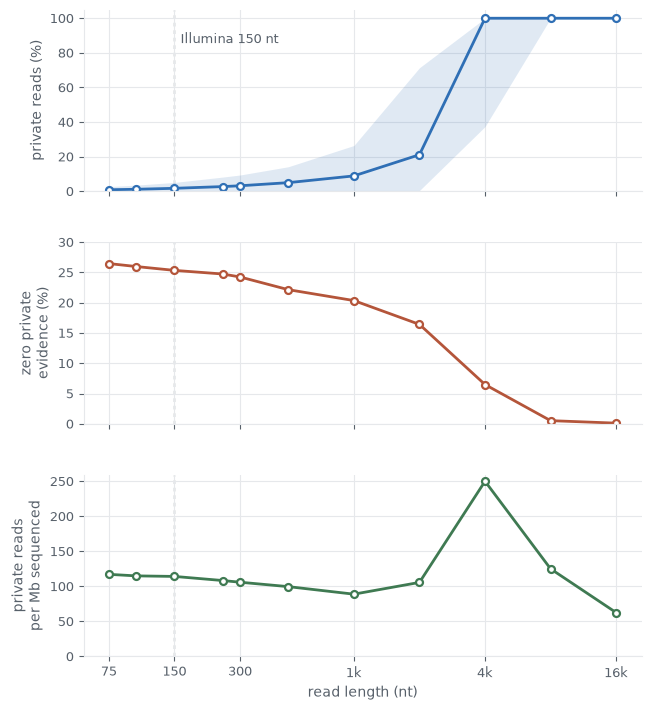

,private % (p25),private % (median),private % (p75),zero evidence %,private reads / Mb,tx shorter than read %
read length,,,,,,
75,0.0,0.9,2.7,26.5,117.0,0.0
100,0.0,1.1,3.5,26.0,115.0,0.0
150,0.0,1.7,5.1,25.3,114.0,0.0
250,0.0,2.7,8.2,24.7,108.0,0.0
300,0.0,3.2,9.4,24.3,106.0,0.0
500,0.0,5.0,14.2,22.2,100.0,0.1
1000,0.1,8.9,26.4,20.4,89.0,1.9
2000,0.4,21.1,71.4,16.4,106.0,11.6
4000,37.4,100.0,100.0,6.5,250.0,56.8


In [23]:
import matplotlib.ticker as mticker

# ---- aggregate ------------------------------------------------------------
q = (pf.groupby("read_length")["frac"]
       .agg(p25=lambda s: s.quantile(.25), p50="median",
            p75=lambda s: s.quantile(.75)).reset_index())
z = (pf.groupby("read_length")["frac"]
       .apply(lambda s: 100 * (s == 0).mean()).reset_index(name="zero_pct"))

# per megabase of sequencing, not per read
pf = pf.assign(per_mb=lambda d: d.frac * 1e6 / d.read_length)
e = (pf.groupby("read_length")["per_mb"].median().reset_index(name="priv_per_mb"))

# how much of the curve is the R >= L regime change
sat = (pf.assign(short=lambda d: d.tx_len <= d.read_length)
         .groupby("read_length")["short"]
         .apply(lambda s: 100 * s.mean()).reset_index(name="tx_shorter_pct"))

print("Chlamydomonas, 300 most isoform-rich genes, 2,668 transcripts")
print("Panel 1  share of a transcript's reads that identify it uniquely (median, IQR)")
print("Panel 2  transcripts observable only by subtraction")
print("Panel 3  private reads per megabase sequenced (equal budget, not equal read count)")
print()

INK, MUTED, GRID = "#1f2328", "#57606a", "#e6e8eb"
BLUE, RUST, GREEN = "#2f6fb5", "#b4553a", "#3f7a52"
TICKS = [75, 150, 300, 1000, 4000, 16000]

fig, axes = plt.subplots(3, 1, figsize=(7.2, 8.4), sharex=True,
                         gridspec_kw={"hspace": 0.28})
ax1, ax2, ax3 = axes

ax1.fill_between(q.read_length, q.p25*100, q.p75*100, color=BLUE, alpha=.15, lw=0)
ax1.plot(q.read_length, q.p50*100, color=BLUE, lw=2, marker="o", ms=5,
         mfc="white", mec=BLUE, mew=1.6)
ax1.set_ylabel("private reads (%)", color=MUTED)
ax1.set_ylim(0, 105)

ax2.plot(z.read_length, z.zero_pct, color=RUST, lw=2, marker="o", ms=5,
         mfc="white", mec=RUST, mew=1.6)
ax2.set_ylabel("zero private\nevidence (%)", color=MUTED)
ax2.set_ylim(0, 30)

ax3.plot(e.read_length, e.priv_per_mb, color=GREEN, lw=2, marker="o", ms=5,
         mfc="white", mec=GREEN, mew=1.6)
ax3.set_ylabel("private reads\nper Mb sequenced", color=MUTED)
ax3.set_xlabel("read length (nt)", color=MUTED)
ax3.set_ylim(bottom=0)

for ax in axes:
    ax.set_xscale("log")
    ax.set_xticks(TICKS)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{v/1000:g}k" if v >= 1000 else f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

# Illumina marker on every panel, labelled once, inside the axes
for ax in axes:
    ax.axvline(150, color=MUTED, lw=0.9, ls=(0, (3, 3)), zorder=0)
ax1.text(160, 92, "Illumina 150 nt", color=MUTED, fontsize=9, va="top")

plt.show()

# ---- the numbers, including what drives the cliff -------------------------
tbl = (q.assign(**{"private % (p25)": (q.p25*100).round(1),
                   "private % (median)": (q.p50*100).round(1),
                   "private % (p75)": (q.p75*100).round(1)})
         .drop(columns=["p25", "p50", "p75"])
         .merge(z.round(1), on="read_length")
         .merge(e.round(0), on="read_length")
         .merge(sat.round(1), on="read_length")
         .rename(columns={"read_length": "read length",
                          "zero_pct": "zero evidence %",
                          "priv_per_mb": "private reads / Mb",
                          "tx_shorter_pct": "tx shorter than read %"})
         .set_index("read length"))
tbl